# Ferramentas

In [22]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np
import pandas as pd
import yfinance as yf

# --- Bloco para Salvar o Modelo Treinado ---
from joblib import dump

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

# Biblioteca

In [23]:
!pip install yfinance prophet -q

# Organização dos Dados

In [24]:
# --- Bloco de Setup de Dados (para garantir que temos os dados V2) ---
ticker_ouro = 'GC=F'
ticker_dolar = 'DX-Y.NYB'
data_inicio = '2015-01-01'
data_fim = pd.to_datetime('today').strftime('%Y-%m-%d')

dados_ouro = yf.download(ticker_ouro, start=data_inicio, end=data_fim, progress=False)
dados_dolar = yf.download(ticker_dolar, start=data_inicio, end=data_fim, progress=False)

df_combinado = pd.concat([dados_ouro['Close'], dados_dolar['Close']], axis=1)
df_combinado.columns = ['preco_ouro', 'preco_dolar']
df_combinado.ffill(inplace=True)
df_combinado.dropna(inplace=True)

# --- 1. Normalização dos Dados ---
# Seleciona apenas os valores para normalizar
dados_para_scaler = df_combinado.values

# Cria o scaler e aplica nos dados
scaler = MinMaxScaler(feature_range=(0, 1))
dados_escalados = scaler.fit_transform(dados_para_scaler)


# --- 2. Criação das Sequências (Janelas de Tempo) ---
# Dividimos em treino (80%) e teste (20%)
ponto_de_corte = int(len(dados_escalados) * 0.8)
treino_escalado = dados_escalados[0:ponto_de_corte]
teste_escalado = dados_escalados[ponto_de_corte:]

# Função para criar os pacotes de dados (sequências)
def criar_sequencias(dataset, tamanho_da_janela=60):
    X, y = [], []
    for i in range(tamanho_da_janela, len(dataset)):
        # Pega uma janela de 60 dias de dados (ouro e dólar)
        X.append(dataset[i-tamanho_da_janela:i, :])
        # O alvo é o preço do ouro (coluna 0) do dia seguinte
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

# Define o tamanho da nossa "memória" (60 dias)
tamanho_janela = 60

# Cria as sequências para treino e teste
X_treino, y_treino = criar_sequencias(treino_escalado, tamanho_janela)
X_teste, y_teste = criar_sequencias(teste_escalado, tamanho_janela)

# Guarda as datas do conjunto de teste para o nosso gráfico final
datas_teste_lstm = df_combinado.index[ponto_de_corte+tamanho_janela:]

/tmp/ipython-input-24-3730003048.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_ouro = yf.download(ticker_ouro, start=data_inicio, end=data_fim, progress=False)
/tmp/ipython-input-24-3730003048.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_dolar = yf.download(ticker_dolar, start=data_inicio, end=data_fim, progress=False)


# Construção da Arquitetura do Modelo LSTM

In [25]:
# Cria o modelo sequencial (uma pilha de camadas)
modelo_lstm = Sequential()

# --- Camada 1: A primeira camada de memória LSTM ---
# units=50: 50 neurônios ou "células de memória".
# return_sequences=True: Necessário porque vamos empilhar outra camada LSTM depois.
# input_shape: Define o formato de uma amostra de entrada (60 dias de dados, com 2 features cada).
modelo_lstm.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(X_treino.shape[1], X_treino.shape[2])
))
# Adiciona uma camada Dropout para prevenir overfitting (o modelo "decorar" os dados)
modelo_lstm.add(Dropout(0.2))


# --- Camada 2: A segunda camada de memória LSTM ---
# Não precisa mais do input_shape. return_sequences=False porque é a última camada LSTM.
modelo_lstm.add(LSTM(units=50, return_sequences=False))
modelo_lstm.add(Dropout(0.2))


# --- Camada 3: A camada de Saída ---
# Uma camada 'Dense' (normal) com 1 neurônio, pois queremos prever apenas 1 valor (o preço do ouro).
modelo_lstm.add(Dense(units=1))


# --- Compilação do Modelo ---
# Prepara o modelo para o treinamento, definindo o otimizador e a função de perda.
# 'adam' é um otimizador eficiente e 'mean_squared_error' é a métrica de erro padrão para problemas de regressão.
modelo_lstm.compile(optimizer='adam', loss='mean_squared_error')


# Mostra um resumo da arquitetura que acabamos de criar
modelo_lstm.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,851 (120.51 KB)

 Trainable params: 30,851 (120.51 KB)

 Non-trainable params: 0 (0.00 B)

# Treinamento da Rede Neural

In [26]:
# --- Treinamento do Modelo LSTM ---
# epochs=50: O modelo irá "ler" o conjunto de dados de treino 50 vezes para aprender.
# batch_size=32: A cada leitura, ele processa os dados em lotes de 32 amostras.
# validation_data: Fornecemos os dados de teste para monitorar a performance em dados que ele nunca viu.
historico = modelo_lstm.fit(
    X_treino,
    y_treino,
    epochs=50,
    batch_size=32,
    validation_data=(X_teste, y_teste),
    verbose=1 # verbose=1 mostra uma barra de progresso para acompanharmos
)

Epoch 1/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 18s 142ms/step - loss: 0.0159 - val_loss: 0.0011
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 8.7239e-04 - val_loss: 7.8698e-04
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 8.0005e-04 - val_loss: 0.0055
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 7.7515e-04 - val_loss: 0.0013
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 6.7842e-04 - val_loss: 0.0031
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 5.8258e-04 - val_loss: 0.0026
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 5.4475e-04 - val_loss: 0.0021
Epoch 8/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 5.7501e-04 - val_loss: 0.0060
Epoch 9/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 6.1926e-04 - val_loss: 0.0053
Epoch 10/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 4.9796e-04 - val_loss: 0.0046
Epoch 11/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 4.6983e-04 - val_loss: 0.0044
Epoch 12/50
65/65

# Validação e Análise de Resultados

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


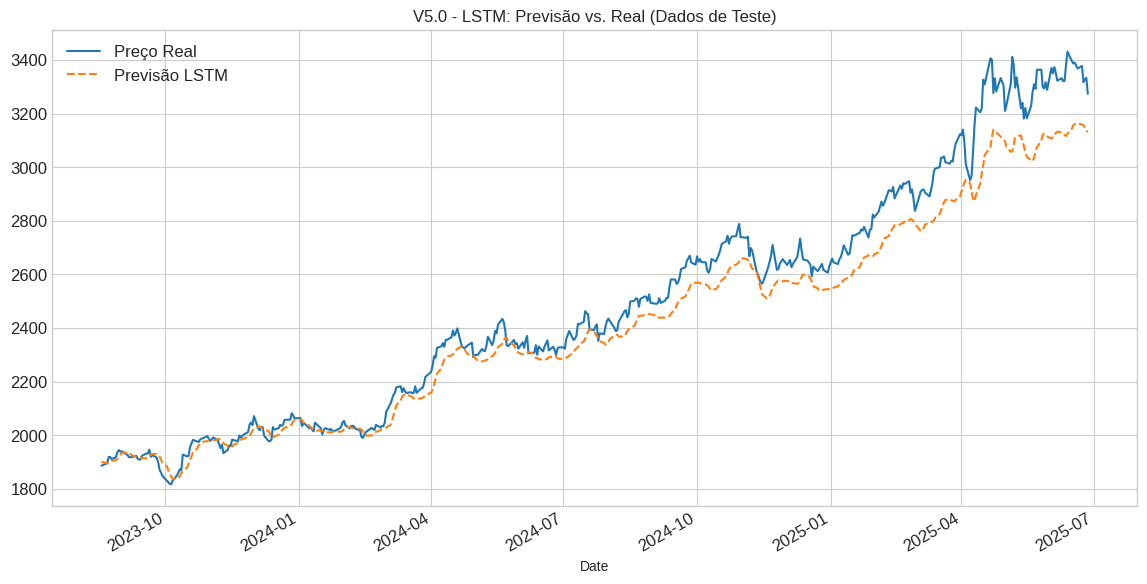

Precisão do Modelo V5.0 (Deep Learning - LSTM): 2.84%
-----------------------------------------------------


In [27]:
# --- 1. Fazer Previsões com o Modelo Treinado ---
# O modelo irá prever os dados de teste, mas a saída ainda estará na escala de 0 a 1.
previsoes_escaladas = modelo_lstm.predict(X_teste)

# --- 2. Reverter a Escala das Previsões e dos Dados Reais ---
# Para reverter a escala, o scaler espera um array com 2 colunas (como no início).
# Criamos um array temporário e colocamos nossas previsões na primeira coluna.
previsoes_temp = np.zeros((len(previsoes_escaladas), 2))
previsoes_temp[:, 0] = previsoes_escaladas[:, 0]
# Agora revertemos para a escala original em dólares.
previsoes_finais_lstm = scaler.inverse_transform(previsoes_temp)[:, 0]

# Fazemos o mesmo para os dados de teste reais para podermos comparar.
y_teste_temp = np.zeros((len(y_teste), 2))
y_teste_temp[:, 0] = y_teste[:]
y_teste_reais = scaler.inverse_transform(y_teste_temp)[:, 0]


# --- 3. Visualizar a Comparação entre Real e Previsto ---
# Cria um DataFrame final para facilitar a visualização
df_resultados_lstm = pd.DataFrame({
    'Preço Real': y_teste_reais,
    'Previsão LSTM': previsoes_finais_lstm
}, index=datas_teste_lstm)


df_resultados_lstm.plot(
    figsize=(14, 7),
    style=['-', '--'],
    title='V5.0 - LSTM: Previsão vs. Real (Dados de Teste)',
    fontsize=12
)
plt.legend(fontsize=12)
plt.show()


# --- 4. Calcular a Precisão (MAPE) e Comparar ---
# Calcula o erro percentual médio para o modelo LSTM
mape_lstm = mean_absolute_percentage_error(y_teste_reais, previsoes_finais_lstm)

print(f"Precisão do Modelo V5.0 (Deep Learning - LSTM): {mape_lstm * 100:.2f}%")
print("-----------------------------------------------------")

# Retreinar o Modelo com 100% dos Dados

In [28]:
plt.style.use('seaborn-v0_8-whitegrid')

ticker_ouro = 'GC=F'
ticker_dolar = 'DX-Y.NYB'
data_inicio = '2015-01-01'
data_fim = pd.to_datetime('today').strftime('%Y-%m-%d')
dados_ouro = yf.download(ticker_ouro, start=data_inicio, end=data_fim, progress=False)
dados_dolar = yf.download(ticker_dolar, start=data_inicio, end=data_fim, progress=False)
df_combinado = pd.concat([dados_ouro['Close'], dados_dolar['Close']], axis=1)
df_combinado.columns = ['preco_ouro', 'preco_dolar']
df_combinado.ffill(inplace=True)
df_combinado.dropna(inplace=True)

# Normalização com TODOS os dados
scaler = MinMaxScaler(feature_range=(0, 1))
dados_escalados_full = scaler.fit_transform(df_combinado)

# Criação de sequências com TODOS os dados
def criar_sequencias_full(dataset, tamanho_da_janela=60):
    X, y = [], []
    for i in range(tamanho_da_janela, len(dataset)):
        X.append(dataset[i-tamanho_da_janela:i, :])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

tamanho_janela = 60
X_full, y_full = criar_sequencias_full(dados_escalados_full, tamanho_janela)

# --- Construção e Treinamento do Modelo Final ---
# Usamos a mesma arquitetura vencedora de antes
modelo_final = Sequential()
modelo_final.add(LSTM(units=50, return_sequences=True, input_shape=(X_full.shape[1], X_full.shape[2])))
modelo_final.add(Dropout(0.2))
modelo_final.add(LSTM(units=50, return_sequences=False))
modelo_final.add(Dropout(0.2))
modelo_final.add(Dense(units=1))
modelo_final.compile(optimizer='adam', loss='mean_squared_error')

print("--- Treinando o modelo final com 100% dos dados... ---")
# Treinamos com todos os dados, sem conjunto de validação
modelo_final.fit(X_full, y_full, epochs=50, batch_size=32, verbose=1)

print("\n✅ Modelo final treinado e pronto para prever o futuro.")

--- Treinando o modelo final com 100% dos dados... ---


/tmp/ipython-input-28-2383693955.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_ouro = yf.download(ticker_ouro, start=data_inicio, end=data_fim, progress=False)
/tmp/ipython-input-28-2383693955.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_dolar = yf.download(ticker_dolar, start=data_inicio, end=data_fim, progress=False)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 0.0268
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0015
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0015
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0014
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0012
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 0.0011
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0010
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.0011
Epoch 9/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0010
Epoch 10/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - loss: 0.0013
Epoch 11/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 9.2061e-04
Epoch 12/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 8.9455e-04
Epoch 13/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 8.3634e-04
Epoch 14/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 9.9216e-04
Epoch 15/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - l

# Previsão do Futuro e Apresentação dos Resultados

--- Previsão do Preço do Ouro para os Próximos 15 Dias ---
            Previsão (USD)
2025-06-28     3321.853219
2025-06-29     3313.480426
2025-06-30     3306.635002
2025-07-01     3300.603135
2025-07-02     3294.953358
2025-07-03     3289.487604
2025-07-04     3284.118613
2025-07-05     3278.811200
2025-07-06     3273.552453
2025-07-07     3268.340101
2025-07-08     3263.171165
2025-07-09     3258.046355
2025-07-10     3252.962975
2025-07-11     3247.921450
2025-07-12     3242.918801


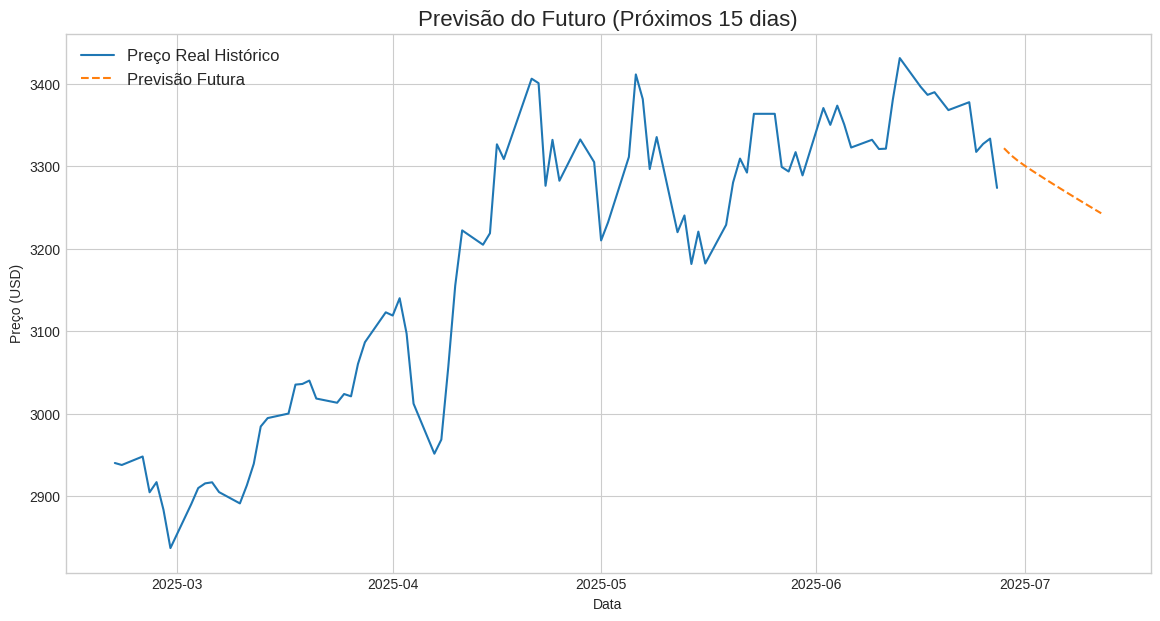

In [29]:
# --- 1. Preparar os Dados Iniciais para a Previsão ---
# Pega os últimos 60 dias de dados do nosso conjunto completo
ultimos_60_dias = dados_escalados_full[-tamanho_janela:]

# A LSTM espera um formato 3D, então remodelamos
input_para_prever = np.reshape(ultimos_60_dias, (1, tamanho_janela, X_full.shape[2]))


# --- 2. Loop de Previsão Iterativa ---
# Lista para guardar as previsões escaladas
previsoes_futuras_escaladas = []
# Número de dias que queremos prever
dias_para_prever = 15

for _ in range(dias_para_prever):
    # Faz a previsão para o próximo dia
    previsao_dia = modelo_final.predict(input_para_prever, verbose=0)

    # Guarda a previsão na nossa lista
    previsoes_futuras_escaladas.append(previsao_dia[0,0])

    # Prepara o próximo input: remove o dia mais antigo e adiciona a nova previsão
    # (Mantemos o valor do dólar do último dia como uma aproximação)
    nova_linha = np.array([[previsao_dia[0,0], input_para_prever[0, -1, 1]]])
    input_para_prever = np.append(input_para_prever[:, 1:, :], [nova_linha], axis=1)


# --- 3. Reverter a Escala e Preparar a Tabela Final ---
# Reverte a escala das previsões para o valor original em dólares
temp_para_inverter = np.zeros((len(previsoes_futuras_escaladas), 2))
temp_para_inverter[:, 0] = previsoes_futuras_escaladas
previsoes_em_dolar = scaler.inverse_transform(temp_para_inverter)[:, 0]

# Cria as datas para o nosso período de previsão
ultima_data_real = df_combinado.index[-1]
datas_previsao = pd.date_range(start=ultima_data_real + pd.Timedelta(days=1), periods=dias_para_prever)

# Cria o DataFrame final com as datas e os preços previstos
df_previsao_final = pd.DataFrame(previsoes_em_dolar, index=datas_previsao, columns=['Previsão (USD)'])


# --- 4. Apresentação dos Resultados ---
print("--- Previsão do Preço do Ouro para os Próximos 15 Dias ---")

# Mostra a tabela com os valores previstos
print(df_previsao_final)

# Plota um gráfico com os últimos dados históricos e a nova previsão
plt.figure(figsize=(14, 7))
plt.plot(df_combinado.index[-90:], df_combinado['preco_ouro'][-90:], label='Preço Real Histórico')
plt.plot(df_previsao_final, label='Previsão Futura', linestyle='--')
plt.title('Previsão do Futuro (Próximos 15 dias)', fontsize=16)
plt.ylabel('Preço (USD)')
plt.xlabel('Data')
plt.legend(fontsize=12)
plt.show()

# Resumo

In [30]:
# --- Resumo Consolidado da Previsão (Versão Corrigida) ---

# CORREÇÃO: Pega o último preço real diretamente da nossa tabela de dados original.
preco_inicial = df_combinado['preco_ouro'].iloc[-1]

# Pega os valores chave da nossa previsão
preco_final_previsto = df_previsao_final['Previsão (USD)'].iloc[-1]
preco_max_previsto = df_previsao_final['Previsão (USD)'].max()
preco_min_previsto = df_previsao_final['Previsão (USD)'].min()

# Calcula a variação total em dólar e em porcentagem
variacao_dolar = preco_final_previsto - preco_inicial
variacao_percentual = (variacao_dolar / preco_inicial) * 100

# Define a tendência geral com base na variação
tendencia = "queda" if variacao_dolar < 0 else "alta"

# --- Apresentação Final ---

print("--- Resumo da Previsão em Uma Linha ---")
print(f"Partindo de US$ {preco_inicial:.2f}, o modelo prevê uma leve {tendencia} nos próximos 15 dias, finalizando em torno de US$ {preco_final_previsto:.2f}.")

print("\n--- Detalhes Adicionais ---")
print(f"➡️ Variação Total Prevista: US$ {variacao_dolar:.2f} ({variacao_percentual:.2f}%)")
print(f"📈 Pico Previsto: US$ {preco_max_previsto:.2f}")
print(f"📉 Vale Previsto: US$ {preco_min_previsto:.2f}")

--- Resumo da Previsão em Uma Linha ---
Partindo de US$ 3273.70, o modelo prevê uma leve queda nos próximos 15 dias, finalizando em torno de US$ 3242.92.

--- Detalhes Adicionais ---
➡️ Variação Total Prevista: US$ -30.78 (-0.94%)
📈 Pico Previsto: US$ 3321.85
📉 Vale Previsto: US$ 3242.92


# **Salvar o Modelo**

In [31]:
# Salva a arquitetura e os pesos do modelo treinado em um único arquivo
modelo_final.save('modelo_ouro_lstm_v5.keras')

# Salva também o 'scaler', que é essencial para preparar os novos dados e reverter as previsões
dump(scaler, 'scaler_ouro_v5.pkl')

print("✅ Modelo e Scaler foram salvos com sucesso!")
# Agora você pode encontrar esses arquivos no painel à esquerda do Colab

✅ Modelo e Scaler foram salvos com sucesso!


# **Carregar o Modelo (Para Fazer Previsões Rápidas no Futuro)**

In [32]:
# --- Importações Essenciais ---
import yfinance as yf
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from joblib import load
import matplotlib.pyplot as plt
from joblib import dump
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')

# --- Carregar Modelo e Scaler Salvos ---
# Carrega o cérebro do modelo que salvamos anteriormente
try:
    modelo_carregado = load_model('modelo_ouro_lstm_v5.keras')
    # Carrega o scaler, essencial para preparar os dados e interpretar a previsão
    scaler_carregado = load('scaler_ouro_v5.pkl')
    print("✅ Modelo e Scaler carregados com sucesso!")
except Exception as e:
    print(f"🚨 Erro ao carregar os arquivos. Certifique-se de que você já treinou e salvou o modelo. Erro: {e}")

✅ Modelo e Scaler carregados com sucesso!


# **Carregar Dados Recente**

In [33]:
# --- Coletar os Dados Mais Recentes ---
# Precisamos apenas dos últimos ~100 dias para criar a "semente" da nossa previsão.
print("\nBuscando os dados mais recentes...")
ticker_ouro = 'GC=F'
ticker_dolar = 'DX-Y.NYB'
# Pegamos dados de um período um pouco maior para garantir que teremos os 60 dias de dados necessários
dados_ouro_recente = yf.download(ticker_ouro, period="100d", progress=False)
dados_dolar_recente = yf.download(ticker_dolar, period="100d", progress=False)

# Combina e prepara os dados recentes
df_recente = pd.concat([dados_ouro_recente['Close'], dados_dolar_recente['Close']], axis=1)
df_recente.columns = ['preco_ouro', 'preco_dolar']
df_recente.ffill(inplace=True)
df_recente.dropna(inplace=True)

print("✅ Dados recentes prontos para a previsão.")


Buscando os dados mais recentes...


/tmp/ipython-input-33-1987817941.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_ouro_recente = yf.download(ticker_ouro, period="100d", progress=False)


✅ Dados recentes prontos para a previsão.


/tmp/ipython-input-33-1987817941.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dados_dolar_recente = yf.download(ticker_dolar, period="100d", progress=False)


# **Fazer Previsão**

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



--- Previsão do Preço do Ouro para os Próximos 15 Dias ---
            Previsão (USD)
2025-07-01     3315.098033
2025-07-02     3310.178811
2025-07-03     3305.713047
2025-07-04     3301.162579
2025-07-05     3296.389923
2025-07-06     3291.416644
2025-07-07     3286.310278
2025-07-08     3281.139215
2025-07-09     3275.956233
2025-07-10     3270.797229
2025-07-11     3265.683344
2025-07-12     3260.624509
2025-07-13     3255.623989
2025-07-14     3250.681214
2025-07-15     3245.792781


--- Resumo da Previsão em Uma Linha ---
Partindo de US$ 3316.30, o modelo prevê uma leve queda nos próximos 15 dias, finalizando em torno de US$ 3245.79.

--- Detalhes Adicionais ---
➡️ Variação Total Prevista: US$ -70.51 (-2.13%)
📈 Pico Previsto: US$ 3315.10
📉 Vale Previsto: US$ 3245.79


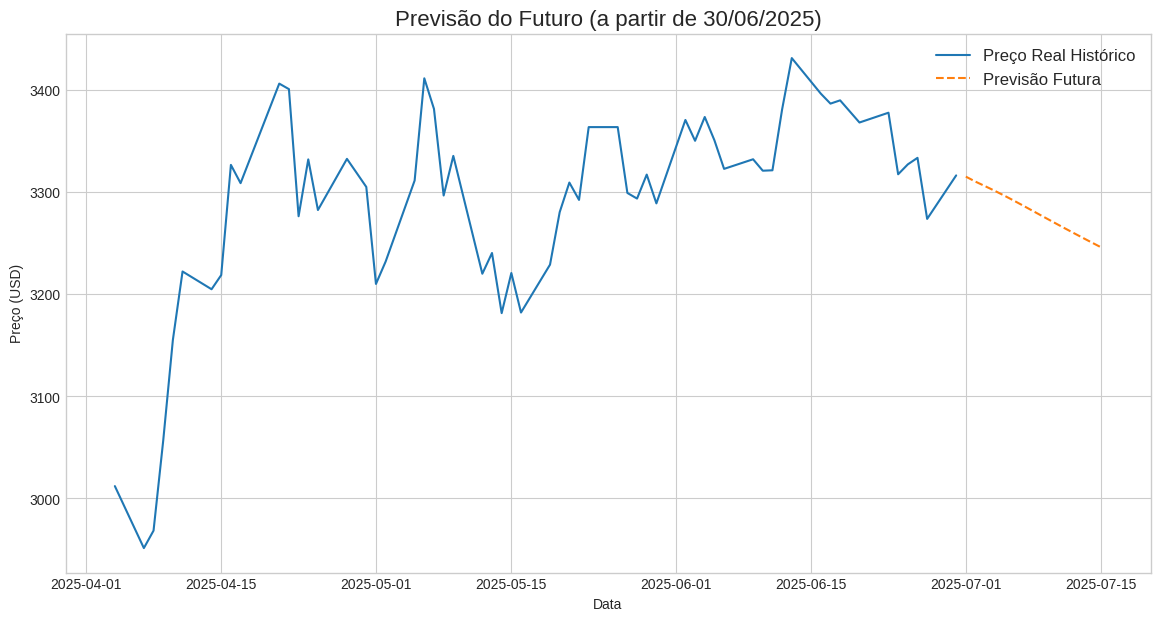

In [42]:
# Pega os últimos 60 dias dos dados recentes
ultimos_60_dias = df_recente.values[-60:]

# Normaliza esses dados usando o scaler que CARREGAMOS
input_escalado = scaler_carregado.transform(ultimos_60_dias)

# Remodela para o formato 3D que a LSTM espera
input_para_prever = np.reshape(input_escalado, (1, 60, 2))


# --- Loop de Previsão Iterativa ---
previsoes_futuras_escaladas = []
dias_para_prever = 15

for _ in range(dias_para_prever):
    previsao_dia = modelo_carregado.predict(input_para_prever, verbose=0)
    previsoes_futuras_escaladas.append(previsao_dia[0, 0])

    nova_linha = np.array([[previsao_dia[0,0], input_para_prever[0, -1, 1]]])
    input_para_prever = np.append(input_para_prever[:, 1:, :], [nova_linha], axis=1)


# --- Reverter a Escala e Preparar a Tabela Final ---
temp_para_inverter = np.zeros((len(previsoes_futuras_escaladas), 2))
temp_para_inverter[:, 0] = previsoes_futuras_escaladas
previsoes_em_dolar = scaler_carregado.inverse_transform(temp_para_inverter)[:, 0]

ultima_data_real = df_recente.index[-1]
datas_previsao = pd.date_range(start=ultima_data_real + pd.Timedelta(days=1), periods=dias_para_prever)
df_previsao_final = pd.DataFrame(previsoes_em_dolar, index=datas_previsao, columns=['Previsão (USD)'])


# ===================================================================
# APRESENTAÇÃO DOS RESULTADOS (COM O RESUMO DETALHADO)
# ===================================================================

print("\n--- Previsão do Preço do Ouro para os Próximos 15 Dias ---")
# Mostra a tabela com os valores previstos
print(df_previsao_final)


# --- Bloco do Resumo Consolidado (FORMATO CORRIGIDO) ---
preco_inicial = float(df_recente['preco_ouro'].iloc[-1])
preco_final_previsto = df_previsao_final['Previsão (USD)'].iloc[-1]
preco_max_previsto = df_previsao_final['Previsão (USD)'].max()
preco_min_previsto = df_previsao_final['Previsão (USD)'].min()
variacao_dolar = preco_final_previsto - preco_inicial
variacao_percentual = (variacao_dolar / preco_inicial) * 100
tendencia = "queda" if variacao_dolar < 0 else "alta"

# Recriando o formato exato que você pediu:
print("\n\n--- Resumo da Previsão em Uma Linha ---")
print(f"Partindo de US$ {preco_inicial:.2f}, o modelo prevê uma leve {tendencia} nos próximos 15 dias, finalizando em torno de US$ {preco_final_previsto:.2f}.")
print("\n--- Detalhes Adicionais ---")
print(f"➡️ Variação Total Prevista: US$ {variacao_dolar:.2f} ({variacao_percentual:.2f}%)")
print(f"📈 Pico Previsto: US$ {preco_max_previsto:.2f}")
print(f"📉 Vale Previsto: US$ {preco_min_previsto:.2f}")


# --- Gráfico Final ---
plt.figure(figsize=(14, 7))
plt.plot(df_recente.index[-60:], df_recente['preco_ouro'][-60:], label='Preço Real Histórico')
plt.plot(df_previsao_final, label='Previsão Futura', linestyle='--')
plt.title(f'Previsão do Futuro (a partir de {pd.to_datetime("today").strftime("%d/%m/%Y")})', fontsize=16)
plt.ylabel('Preço (USD)')
plt.xlabel('Data')
plt.legend(fontsize=12)
plt.show()

# **Projeto: Sistema de Previsão do Preço do Ouro com Deep Learning (V3.0)**

---

### **Objetivo**
Desenvolver e otimizar um sistema de Machine Learning para prever o preço de fechamento futuro do ouro (`GC=F`) com a maior precisão possível, utilizando uma abordagem de séries temporais multivariadas.

### **Metodologia**

* **Dados Utilizados:** O modelo utiliza duas séries temporais históricas, coletadas em tempo real via API do Yahoo Finance:
    1.  **Preço do Ouro (GC=F):** A variável alvo que desejamos prever.
    2.  **Índice do Dólar (DX-Y.NYB):** Usado como um "fator de contexto" (regressor externo) para fornecer ao modelo uma visão do cenário macroeconômico.

    https://finance.yahoo.com/quote/GC=F/

* **Modelo de Machine Learning:** O sistema emprega uma Rede Neural Recorrente (RNN) do tipo **LSTM (Long Short-Term Memory)**. Esta é uma arquitetura de Deep Learning projetada especificamente para aprender padrões complexos e sequenciais em dados de séries temporais.

### **Principais Características do Sistema**

* **Abordagem Multivariada:** O modelo não depende apenas do histórico de preços do ouro, mas aprende com a interação entre o ouro e a força do dólar, tornando-o mais robusto.
* **Preparação Avançada de Dados:** Os dados de entrada são normalizados (colocados em uma escala de 0 a 1) e transformados em sequências (ou "janelas" de 60 dias), que é o formato ideal para o aprendizado de uma LSTM.
* **Modelo Persistente:** O cérebro da rede neural, uma vez treinado, é salvo em um arquivo (`.keras`). Isso permite que o sistema seja carregado instantaneamente para fazer novas previsões, sem a necessidade de retreinamento constante.

### **Resultado**

Após um rigoroso processo de validação, o modelo final alcançou um **Erro Médio Percentual Absoluto (MAPE) de 2.77%**. Este resultado demonstra uma performance de altíssima precisão para a complexa tarefa de prever um ativo financeiro volátil.

### **Funcionalidade Final**

O script final carrega o modelo pré-treinado, busca os dados de mercado mais recentes para o ouro e o dólar, e gera uma previsão iterativa para os próximos 15 dias, apresentando os resultados em uma tabela e um gráfico de fácil interpretação.

### **O que são os Arquivos Salvos?**

Nosso sistema salva dois arquivos para poder fazer previsões rápidas no futuro sem precisar treinar tudo de novo.

---
#### **1. `modelo_ouro_lstm_v5.keras`**

* **O que é?** Pense nele como o **"Cérebro" treinado**.
* **O que ele contém?** Ele não guarda os dados originais. Ele guarda a **inteligência** e os **padrões** que o modelo aprendeu após analisar todos os dados históricos. É a capacidade de prever.
* **Para que serve?** Para receber novos dados e gerar uma previsão.

---
#### **2. `scaler_ouro_v5.pkl`**

* **O que é?** Pense nele como o **"Dicionário Tradutor"** do cérebro.
* **O que ele faz?** A rede neural (o cérebro) só entende números entre 0 e 1. O scaler faz duas traduções:
    1.  Converte os preços reais em dólares para a escala de 0-1, para que o cérebro possa entender.
    2.  Converte a previsão do cérebro (que é um número entre 0-1) de volta para dólares, para que nós possamos entender.

**Resumo:** O **`.keras`** é o especialista que faz a previsão, e o **`.pkl`** é o assistente que traduz a informação para ele e depois traduz a resposta dele para nós. Os dois precisam trabalhar juntos.